In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
START_DATE = "2025-01-01"

In [3]:
df = pd.read_csv(
    "../predictions/xgboost_preds.csv",
    index_col=0,
    parse_dates=True
)
df = df.loc[df.index >= START_DATE]

In [4]:
TARGET_COL = "yCbin_SP500_4w"

extracting sp500 weekly

In [5]:
weekly_df = pd.read_csv(
    "../prepared_data/weekly_df.csv",
    index_col=0,
    parse_dates=True
)

# keep SP500 only
sp500_weekly = weekly_df[["SP500"]].copy()

# filter by START_DATE
sp500_weekly_2024 = sp500_weekly.loc[sp500_weekly.index >= START_DATE].copy()

print("sp500_weekly_2024 shape:", sp500_weekly_2024.shape)
print(sp500_weekly_2024.head())


sp500_weekly_2024 shape: (52, 1)
                  SP500
2025-01-03  5942.470215
2025-01-10  5827.040039
2025-01-17  5996.660156
2025-01-24  6101.240234
2025-01-31  6040.529785


In [6]:
START_DATE = "2025-01-01"
INITIAL_CAPITAL = 100_000

### Strat: in / out

In [7]:
# =========================
# STEP 2 — First simulation (IN/OUT -> 100% SP500 or 100% cash)
# Assumes:
#   df has: pred_out  (0=IN, 1=OUT)
#   sp500_weekly_2024 has: SP500 (price level)
# =========================

# 1) align SP500 prices to df dates (2024+)
sp = sp500_weekly_2024.reindex(df.index).rename(columns={"SP500": "sp_price"})
sp["sp_ret"] = sp["sp_price"].pct_change()

# 2) build position: IN=0, OUT=1 (from prediction at week t close)
#pos = (df["pred_out"] == 1).astype(int)

# 2) build signal at t, but TRADE it 3 weeks later
pos_signal = (df["pred_out"] == 1).astype(int)   # signal emitted at t
pos = pos_signal.shift(3)                        # active at t+3

# 3) apply position to NEXT week's return (decision at t -> earns t->t+1)
strategy_ret = pos * sp["sp_ret"].shift(-1)

# 4) equity curves
sim = pd.DataFrame(index=df.index)
sim["sp_price"] = sp["sp_price"]
sim["sp_ret"] = sp["sp_ret"]
sim["pos_in"] = pos
sim["strategy_ret"] = strategy_ret

sim["equity_strategy"] = INITIAL_CAPITAL * (1 + sim["strategy_ret"].fillna(0)).cumprod()
sim["equity_buyhold"]  = INITIAL_CAPITAL * (1 + sim["sp_ret"].fillna(0)).cumprod()

print(sim[["pos_in","strategy_ret","equity_strategy","equity_buyhold"]].head(5))
print("\nNaNs check:\n", sim[["pos_in","strategy_ret","equity_strategy","equity_buyhold"]].isna().sum())

            pos_in  strategy_ret  equity_strategy  equity_buyhold
2025-01-03     NaN           NaN    100000.000000   100000.000000
2025-01-10     NaN           NaN    100000.000000    98057.538841
2025-01-17     NaN           NaN    100000.000000   100911.909348
2025-01-24     1.0     -0.009951     99004.949045   102671.784860
2025-01-31     1.0     -0.002407     98766.644205   101650.148285

NaNs check:
 pos_in             3
strategy_ret       4
equity_strategy    0
equity_buyhold     0
dtype: int64


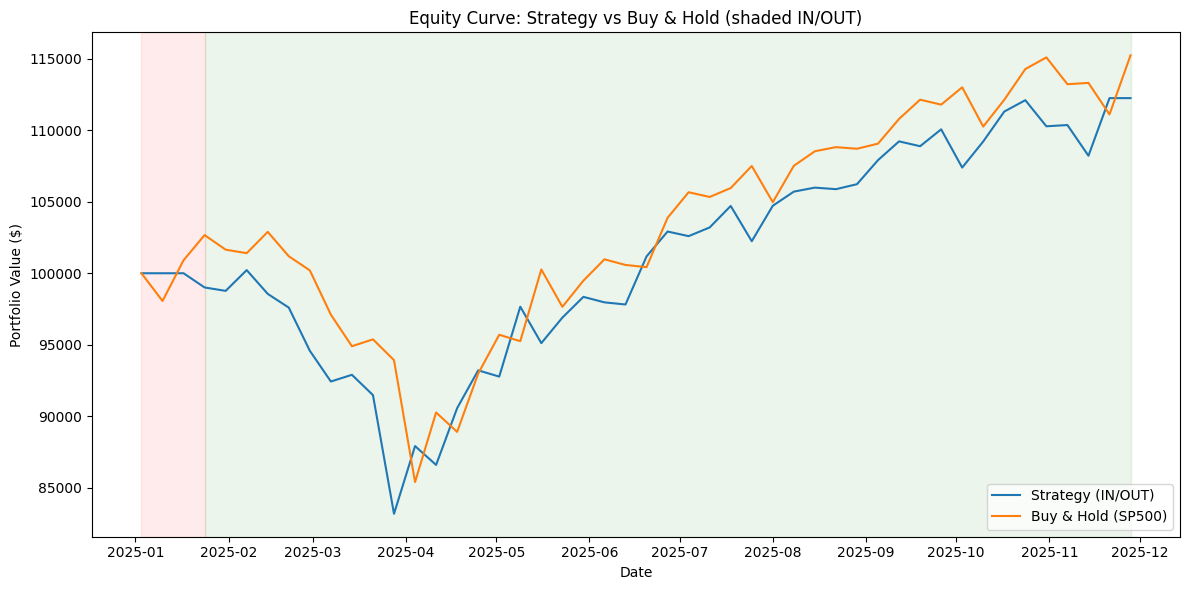

In [8]:
# =========================
# 1) Plot with light shading (IN=green, OUT=red)
# =========================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(sim.index, sim["equity_strategy"], label="Strategy (IN/OUT)")
ax.plot(sim.index, sim["equity_buyhold"], label="Buy & Hold (SP500)")

# Shade regimes (very light)
is_in = sim["pos_in"].fillna(0).astype(int)

start = sim.index[0]
current = is_in.iloc[0]

for i in range(1, len(sim)):
    if is_in.iloc[i] != current:
        end = sim.index[i]
        ax.axvspan(start, end, alpha=0.08, color=("green" if current == 1 else "red"))
        start = end
        current = is_in.iloc[i]

# last segment
ax.axvspan(start, sim.index[-1], alpha=0.08, color=("green" if current == 1 else "red"))

ax.set_title("Equity Curve: Strategy vs Buy & Hold (shaded IN/OUT)")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# =========================
# 2) Summary stats (percent + $ totals) + Sharpe + Alpha (CAPM)
# =========================
import statsmodels.api as sm

final_strat = sim["equity_strategy"].iloc[-1]
final_bh    = sim["equity_buyhold"].iloc[-1]

profit_strat = final_strat - INITIAL_CAPITAL
profit_bh    = final_bh - INITIAL_CAPITAL

pct_strat = (final_strat / INITIAL_CAPITAL - 1) * 100
pct_bh    = (final_bh / INITIAL_CAPITAL - 1) * 100

diff_cash   = final_strat - final_bh
diff_profit = profit_strat - profit_bh
diff_pct    = pct_strat - pct_bh

print("=== Strategy (IN/OUT) ===")
print("Final cash ($):", round(final_strat, 2))
print("Total profit ($):", round(profit_strat, 2))
print("Total return (%):", round(pct_strat, 2))

print("\n=== Buy & Hold SP500 ===")
print("Final cash ($):", round(final_bh, 2))
print("Total profit ($):", round(profit_bh, 2))
print("Total return (%):", round(pct_bh, 2))

print("\n=== Difference (Strategy - Buy&Hold) ===")
print("Final cash diff ($):", round(diff_cash, 2))
print("Profit diff ($):", round(diff_profit, 2))
print("Return diff (% pts):", round(diff_pct, 2))

# -------------------------
# Sharpe + Alpha (weekly)
# -------------------------
# returns used for metrics (make sure these exist in your sim df)
r_p = sim["strategy_ret"].fillna(0.0)     # strategy weekly returns
r_m = sim["sp_ret"].fillna(0.0)           # market weekly returns

# risk-free weekly return:
# - for this IN/OUT cash strategy we assume rf = 0 (cash earns 0)
# - if you prefer to use tbill later, replace with sim["tbill_ret"].
r_f = pd.Series(0.0, index=sim.index)

excess_p = (r_p - r_f).dropna()
excess_m = (r_m - r_f).dropna()

# align
tmp = pd.concat([excess_p.rename("excess_p"), excess_m.rename("excess_m")], axis=1).dropna()

# Sharpe (annualized from weekly)
mu = tmp["excess_p"].mean()
sd = tmp["excess_p"].std(ddof=1)
sharpe_week = mu / sd if sd > 0 else np.nan
sharpe_ann = sharpe_week * np.sqrt(52) if np.isfinite(sharpe_week) else np.nan

# CAPM alpha/beta: excess_p = alpha + beta * excess_m + error
X = sm.add_constant(tmp["excess_m"])
capm = sm.OLS(tmp["excess_p"], X).fit()

alpha_w = capm.params["const"]
beta = capm.params["excess_m"]
alpha_ann = alpha_w * 52

print("\n=== Sharpe + CAPM Alpha (weekly data) ===")
print("Sharpe (ann):", round(sharpe_ann, 4))
print("Beta (vs SP500):", round(beta, 4))
print("Alpha (weekly):", round(alpha_w, 6))
print("Alpha (ann approx):", round(alpha_ann, 4))
print("Alpha p-value:", round(capm.pvalues["const"], 4))

=== Strategy (IN/OUT) ===
Final cash ($): 112257.34
Total profit ($): 12257.34
Total return (%): 12.26

=== Buy & Hold SP500 ===
Final cash ($): 115256.61
Total profit ($): 15256.61
Total return (%): 15.26

=== Difference (Strategy - Buy&Hold) ===
Final cash diff ($): -2999.27
Profit diff ($): -2999.27
Return diff (% pts): -3.0

=== Sharpe + CAPM Alpha (weekly data) ===
Sharpe (ann): 0.8031
Beta (vs SP500): -0.2383
Alpha (weekly): 0.003482
Alpha (ann approx): 0.1811
Alpha p-value: 0.3201


### Strat: in / weekly tbill

In [10]:
# TBILL weekly df (yield or return series - we'll handle next)
tbill_weekly = weekly_df[["US_3M_Treasury"]].copy()

# filter by START_DATE (same as before)
tbill_weekly_2024 = tbill_weekly.loc[tbill_weekly.index >= START_DATE].copy()

print("tbill_weekly_2024 shape:", tbill_weekly_2024.shape)
print(tbill_weekly_2024.head())

tbill_weekly_2024 shape: (52, 1)
            US_3M_Treasury
2025-01-03            4.34
2025-01-10            4.36
2025-01-17            4.34
2025-01-24            4.35
2025-01-31            4.31


In [11]:
# =========================
# OUT asset = 3M T-bill rate (DTB3-style) converted to weekly return
# IN asset  = SP500 weekly return
# =========================

# align tbill yield (%) to sim dates
tb = tbill_weekly_2024.reindex(sim.index).copy()

# convert annualized % yield -> 1-week return (compounded)
tb["tbill_ret"] = (1 + tb["US_3M_Treasury"]/100) ** (7/365) - 1

# next-week returns (decision at t close earns t->t+1)
sp_next = sim["sp_ret"].shift(-1)
tb_next = tb["tbill_ret"].shift(-1)

pos = sim["pos_in"].fillna(1).astype(int)  # 0=IN, 1=OUT

# strategy return: IN -> SP, OUT -> T-bill
sim["tbill_ret"] = tb["tbill_ret"]
sim["strategy_ret_tbill"] = pos * sp_next + (1 - pos) * tb_next

# equity curve
sim["equity_strategy_tbill"] = INITIAL_CAPITAL * (1 + sim["strategy_ret_tbill"].fillna(0)).cumprod()

print(sim[["pos_in","sp_ret","tbill_ret","strategy_ret_tbill","equity_strategy_tbill"]].head(5))
print("\nNaNs in key cols:\n", sim[["tbill_ret","strategy_ret_tbill","equity_strategy_tbill"]].isna().sum())

            pos_in    sp_ret  tbill_ret  strategy_ret_tbill  \
2025-01-03     NaN       NaN   0.000815           -0.019425   
2025-01-10     NaN -0.019425   0.000819            0.029109   
2025-01-17     NaN  0.029109   0.000815            0.017440   
2025-01-24     1.0  0.017440   0.000817           -0.009951   
2025-01-31     1.0 -0.009951   0.000810           -0.002407   

            equity_strategy_tbill  
2025-01-03           98057.538841  
2025-01-10          100911.909348  
2025-01-17          102671.784860  
2025-01-24          101650.148285  
2025-01-31          101405.476452  

NaNs in key cols:
 tbill_ret                0
strategy_ret_tbill       1
equity_strategy_tbill    0
dtype: int64


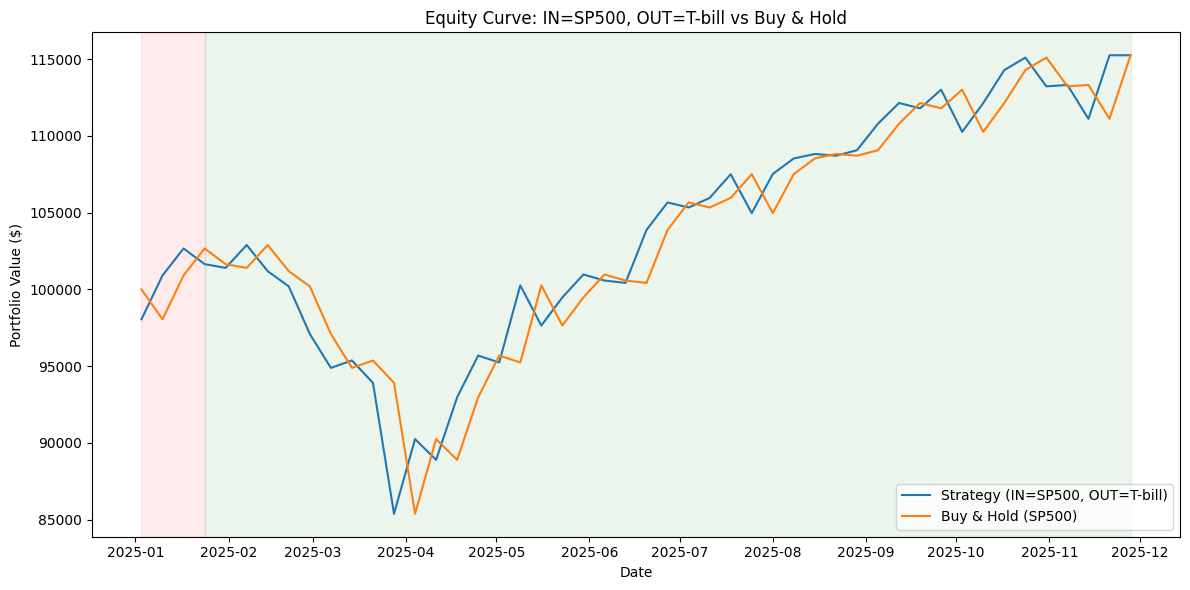

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(sim.index, sim["equity_strategy_tbill"], label="Strategy (IN=SP500, OUT=T-bill)")
ax.plot(sim.index, sim["equity_buyhold"], label="Buy & Hold (SP500)")

# Shade regimes (very light)
is_in = sim["pos_in"].fillna(0).astype(int)

start = sim.index[0]
current = is_in.iloc[0]

for i in range(1, len(sim)):
    if is_in.iloc[i] != current:
        end = sim.index[i]
        ax.axvspan(start, end, alpha=0.08, color=("green" if current == 1 else "red"))
        start = end
        current = is_in.iloc[i]

ax.axvspan(start, sim.index[-1], alpha=0.08, color=("green" if current == 1 else "red"))

ax.set_title("Equity Curve: IN=SP500, OUT=T-bill vs Buy & Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# =========================
# Summary stats + difference vs Buy&Hold (T-bill OUT strat)
# =========================

final_strat = sim["equity_strategy_tbill"].iloc[-1]
final_bh    = sim["equity_buyhold"].iloc[-1]

profit_strat = final_strat - INITIAL_CAPITAL
profit_bh    = final_bh - INITIAL_CAPITAL

pct_strat = (final_strat / INITIAL_CAPITAL - 1) * 100
pct_bh    = (final_bh / INITIAL_CAPITAL - 1) * 100

diff_cash   = final_strat - final_bh
diff_profit = profit_strat - profit_bh
diff_pct    = pct_strat - pct_bh

print("=== Strategy (IN=SP500, OUT=T-bill) ===")
print("Final cash ($):", round(final_strat, 2))
print("Total profit ($):", round(profit_strat, 2))
print("Total return (%):", round(pct_strat, 2))

print("\n=== Buy & Hold SP500 ===")
print("Final cash ($):", round(final_bh, 2))
print("Total profit ($):", round(profit_bh, 2))
print("Total return (%):", round(pct_bh, 2))

print("\n=== Difference (Strategy - Buy&Hold) ===")
print("Final cash diff ($):", round(diff_cash, 2))
print("Profit diff ($):", round(diff_profit, 2))
print("Return diff (% pts):", round(diff_pct, 2))

if profit_bh > 0:
    print("\nProfit multiple (profit_strat / profit_bh):", round(profit_strat / profit_bh, 4), "x")
else:
    print("Profit multiple not meaningful (buy&hold profit <= 0).")

ratio_better = final_strat / final_bh
pct_better_vs_bh = (ratio_better - 1) * 100

print("\n=== Outperformance vs Market ===")
print("Multiple vs Buy&Hold (final_strat / final_bh):", round(ratio_better, 4), "x")
print("Outperformance vs Buy&Hold (%):", round(pct_better_vs_bh, 2))

# -------------------------
# Sharpe + Alpha (weekly)
# -------------------------
r_p = sim["strategy_ret_tbill"].fillna(0.0)
r_m = sim["sp_ret"].fillna(0.0)
r_f = sim["tbill_ret"].fillna(0.0)   # risk-free proxy

tmp = pd.concat([(r_p - r_f).rename("excess_p"), (r_m - r_f).rename("excess_m")], axis=1).dropna()

mu = tmp["excess_p"].mean()
sd = tmp["excess_p"].std(ddof=1)
sharpe_week = mu / sd if sd > 0 else np.nan
sharpe_ann = sharpe_week * np.sqrt(52) if np.isfinite(sharpe_week) else np.nan

X = sm.add_constant(tmp["excess_m"])
capm = sm.OLS(tmp["excess_p"], X).fit()

alpha_w = capm.params["const"]
beta = capm.params["excess_m"]
alpha_ann = alpha_w * 52

print("\n=== Sharpe + CAPM Alpha (weekly data) ===")
print("Sharpe (ann):", round(sharpe_ann, 4))
print("Beta (vs SP500):", round(beta, 4))
print("Alpha (weekly):", round(alpha_w, 6))
print("Alpha (ann approx):", round(alpha_ann, 4))
print("Alpha p-value:", round(capm.pvalues["const"], 4))

=== Strategy (IN=SP500, OUT=T-bill) ===
Final cash ($): 115256.61
Total profit ($): 15256.61
Total return (%): 15.26

=== Buy & Hold SP500 ===
Final cash ($): 115256.61
Total profit ($): 15256.61
Total return (%): 15.26

=== Difference (Strategy - Buy&Hold) ===
Final cash diff ($): 0.0
Profit diff ($): 0.0
Return diff (% pts): 0.0

Profit multiple (profit_strat / profit_bh): 1.0 x

=== Outperformance vs Market ===
Multiple vs Buy&Hold (final_strat / final_bh): 1.0 x
Outperformance vs Buy&Hold (%): 0.0

=== Sharpe + CAPM Alpha (weekly data) ===
Sharpe (ann): 0.7164
Beta (vs SP500): -0.2433
Alpha (weekly): 0.003071
Alpha (ann approx): 0.1597
Alpha p-value: 0.3897


### Strat: in / short

In [14]:
# =========================
# OUT asset = SHORT SP500 (-1x)
# IN asset  = LONG SP500 (+1x)
# =========================

# next-week SP500 return (decision at t close earns t->t+1)
sp_next = sim["sp_ret"].shift(-1)

pos = sim["pos_in"].fillna(1).astype(int)  # 0=IN, 1=OUT

# map position: IN -> +1, OUT -> -1
expo = np.where(pos == 1, 1.0, -1.0)

# strategy return: long when IN, short when OUT
sim["strategy_ret_short"] = expo * sp_next

# equity curve
sim["equity_strategy_short"] = INITIAL_CAPITAL * (1 + sim["strategy_ret_short"].fillna(0)).cumprod()

print(sim[["pos_in","sp_ret","strategy_ret_short","equity_strategy_short"]].head(5))
print("\nNaNs in key cols:\n", sim[["strategy_ret_short","equity_strategy_short"]].isna().sum())

            pos_in    sp_ret  strategy_ret_short  equity_strategy_short
2025-01-03     NaN       NaN           -0.019425           98057.538841
2025-01-10     NaN -0.019425            0.029109          100911.909348
2025-01-17     NaN  0.029109            0.017440          102671.784860
2025-01-24     1.0  0.017440           -0.009951          101650.148285
2025-01-31     1.0 -0.009951           -0.002407          101405.476452

NaNs in key cols:
 strategy_ret_short       1
equity_strategy_short    0
dtype: int64


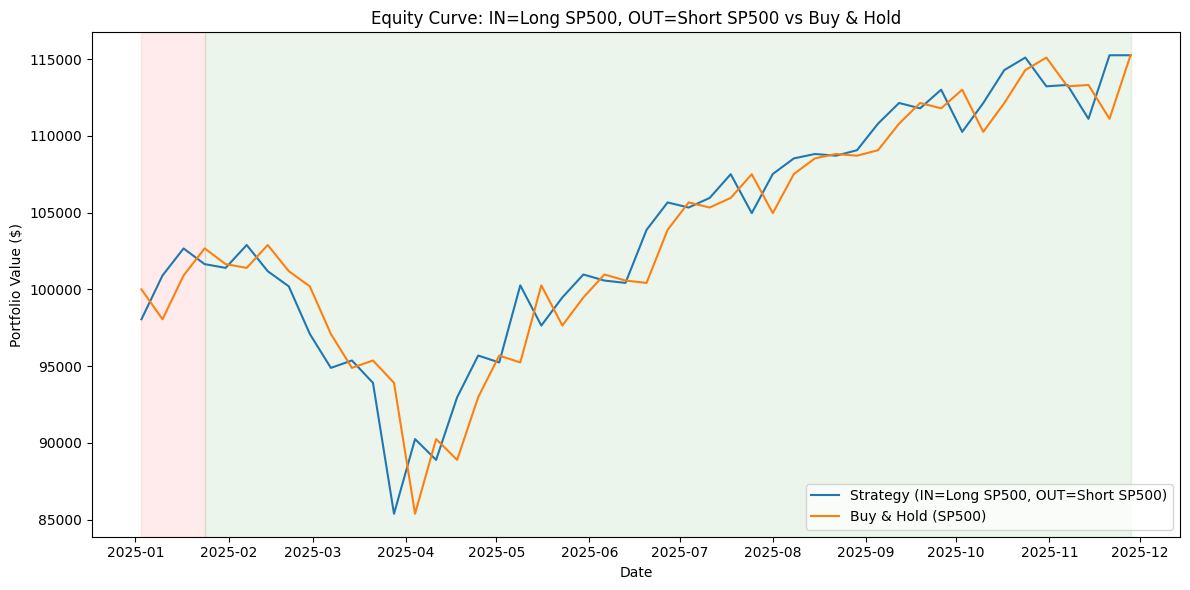

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(sim.index, sim["equity_strategy_short"], label="Strategy (IN=Long SP500, OUT=Short SP500)")
ax.plot(sim.index, sim["equity_buyhold"], label="Buy & Hold (SP500)")

# Shade regimes (very light)
is_in = sim["pos_in"].fillna(0).astype(int)

start = sim.index[0]
current = is_in.iloc[0]

for i in range(1, len(sim)):
    if is_in.iloc[i] != current:
        end = sim.index[i]
        ax.axvspan(start, end, alpha=0.08, color=("green" if current == 1 else "red"))
        start = end
        current = is_in.iloc[i]

ax.axvspan(start, sim.index[-1], alpha=0.08, color=("green" if current == 1 else "red"))

ax.set_title("Equity Curve: IN=Long SP500, OUT=Short SP500 vs Buy & Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# =========================
# Summary stats + difference vs Buy&Hold (SHORT OUT strat)
# =========================

final_strat = sim["equity_strategy_short"].iloc[-1]
final_bh    = sim["equity_buyhold"].iloc[-1]

profit_strat = final_strat - INITIAL_CAPITAL
profit_bh    = final_bh - INITIAL_CAPITAL

pct_strat = (final_strat / INITIAL_CAPITAL - 1) * 100
pct_bh    = (final_bh / INITIAL_CAPITAL - 1) * 100

diff_cash   = final_strat - final_bh
diff_profit = profit_strat - profit_bh
diff_pct    = pct_strat - pct_bh

print("=== Strategy (IN=Long SP500, OUT=Short SP500) ===")
print("Final cash ($):", round(final_strat, 2))
print("Total profit ($):", round(profit_strat, 2))
print("Total return (%):", round(pct_strat, 2))

print("\n=== Buy & Hold SP500 ===")
print("Final cash ($):", round(final_bh, 2))
print("Total profit ($):", round(profit_bh, 2))
print("Total return (%):", round(pct_bh, 2))

print("\n=== Difference (Strategy - Buy&Hold) ===")
print("Final cash diff ($):", round(diff_cash, 2))
print("Profit diff ($):", round(diff_profit, 2))
print("Return diff (% pts):", round(diff_pct, 2))

if profit_bh > 0:
    print("\nProfit multiple (profit_strat / profit_bh):", round(profit_strat / profit_bh, 4), "x")
else:
    print("Profit multiple not meaningful (buy&hold profit <= 0).")

ratio_better = final_strat / final_bh
pct_better_vs_bh = (ratio_better - 1) * 100

print("\n=== Outperformance vs Market ===")
print("Multiple vs Buy&Hold (final_strat / final_bh):", round(ratio_better, 4), "x")
print("Outperformance vs Buy&Hold (%):", round(pct_better_vs_bh, 2))

# -------------------------
# Sharpe + Alpha (weekly)
# -------------------------
r_p = sim["strategy_ret_short"].fillna(0.0)
r_m = sim["sp_ret"].fillna(0.0)

# For the short strategy, keep rf=0 unless you explicitly model financing
r_f = pd.Series(0.0, index=sim.index)

tmp = pd.concat([(r_p - r_f).rename("excess_p"), (r_m - r_f).rename("excess_m")], axis=1).dropna()

mu = tmp["excess_p"].mean()
sd = tmp["excess_p"].std(ddof=1)
sharpe_week = mu / sd if sd > 0 else np.nan
sharpe_ann = sharpe_week * np.sqrt(52) if np.isfinite(sharpe_week) else np.nan

X = sm.add_constant(tmp["excess_m"])
capm = sm.OLS(tmp["excess_p"], X).fit()

alpha_w = capm.params["const"]
beta = capm.params["excess_m"]
alpha_ann = alpha_w * 52

print("\n=== Sharpe + CAPM Alpha (weekly data) ===")
print("Sharpe (ann):", round(sharpe_ann, 4))
print("Beta (vs SP500):", round(beta, 4))
print("Alpha (weekly):", round(alpha_w, 6))
print("Alpha (ann approx):", round(alpha_ann, 4))
print("Alpha p-value:", round(capm.pvalues["const"], 4))

=== Strategy (IN=Long SP500, OUT=Short SP500) ===
Final cash ($): 115256.61
Total profit ($): 15256.61
Total return (%): 15.26

=== Buy & Hold SP500 ===
Final cash ($): 115256.61
Total profit ($): 15256.61
Total return (%): 15.26

=== Difference (Strategy - Buy&Hold) ===
Final cash diff ($): 0.0
Profit diff ($): 0.0
Return diff (% pts): 0.0

Profit multiple (profit_strat / profit_bh): 1.0 x

=== Outperformance vs Market ===
Multiple vs Buy&Hold (final_strat / final_bh): 1.0 x
Outperformance vs Buy&Hold (%): 0.0

=== Sharpe + CAPM Alpha (weekly data) ===
Sharpe (ann): 0.9479
Beta (vs SP500): -0.2433
Alpha (weekly): 0.004064
Alpha (ann approx): 0.2113
Alpha p-value: 0.2582


### SP500 vs probs

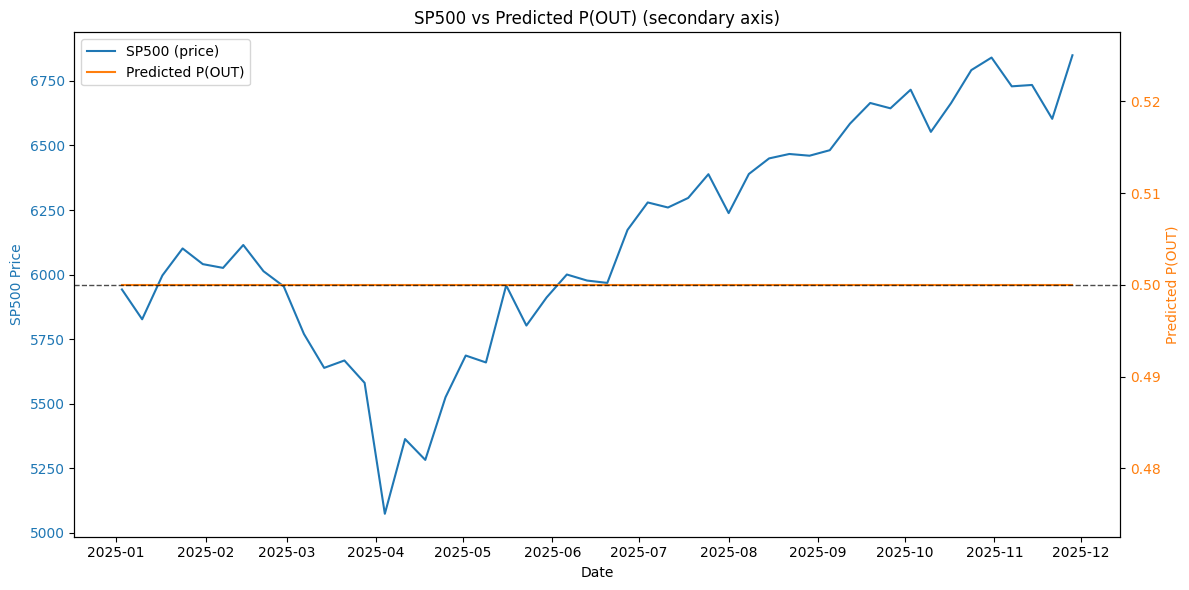

In [17]:
# Align probability series to sim dates
p = df["p_out"].reindex(sim.index)

fig, ax1 = plt.subplots(figsize=(12, 6))

# SP500 (left axis)
ax1.plot(sim.index, sim["sp_price"], label="SP500 (price)", color="tab:blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("SP500 Price", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Predicted probability (right axis)
ax2 = ax1.twinx()
ax2.plot(sim.index, p, label="Predicted P(OUT)", color="tab:orange")
ax2.set_ylabel("Predicted P(OUT)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Horizontal reference line at 0 for probability axis
ax2.axhline(0.5, linestyle="--", linewidth=1, color="black", alpha=0.7)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.title("SP500 vs Predicted P(OUT) (secondary axis)")
plt.tight_layout()
plt.show()